In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, make_scorer, classification_report
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

# Custom OutlierCapper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        sub = X[:, self.col_indices_]
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

# Existing Augmentation Function (Noise and Categorical Swapping)
def augment_data(X, y, num_cols, cat_cols, minority_classes=[0, 2], augmentation_ratio=0.5, noise_scale=0.1, random_state=20):
    np.random.seed(random_state)
    X_aug = X.copy()
    y_aug = y.copy()
    
    # Convert to DataFrame for easier manipulation
    X_df = pd.DataFrame(X_aug, columns=num_cols + cat_cols)
    
    # Augment minority classes
    for cls in minority_classes:
        cls_mask = (y_aug == cls)
        cls_X = X_df[cls_mask]
        cls_y = y_aug[cls_mask]
        n_samples = int(len(cls_X) * augmentation_ratio)
        
        # Numerical features: Add Gaussian noise
        num_noise = np.random.normal(0, noise_scale, (n_samples, len(num_cols)))
        num_aug = cls_X[num_cols].values[:n_samples] + num_noise
        # Clip numerical features to reasonable ranges
        for i, col in enumerate(num_cols):
            if col in ['area_percentage', 'height_percentage']:
                num_aug[:, i] = np.clip(num_aug[:, i], 0, 100)
            elif 'count_' in col:
                num_aug[:, i] = np.clip(num_aug[:, i], 0, None)
                num_aug[:, i] = np.round(num_aug[:, i]).astype(int)
        
        # Categorical features: Randomly swap within the same class
        cat_aug = cls_X[cat_cols].values[:n_samples].copy()
        for col in cat_cols:
            col_idx = X_df.columns.get_loc(col)
            possible_values = X_df.loc[cls_mask, col].unique()
            if len(possible_values) > 1:
                random_choices = np.random.choice(possible_values, size=n_samples, replace=True)
                cat_aug[:, cat_cols.index(col)] = random_choices
        
        # Combine augmented numerical and categorical features
        aug_samples = np.hstack([num_aug, cat_aug])
        X_df_aug = pd.DataFrame(aug_samples, columns=num_cols + cat_cols)
        y_df_aug = np.array([cls] * n_samples)
        
        # Append augmented samples
        X_df = pd.concat([X_df, X_df_aug], ignore_index=True)
        y_aug = np.concatenate([y_aug, y_df_aug])
    
    return X_df, y_aug

2025-04-29 01:37:18.652437: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-29 01:37:18.654860: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-29 01:37:18.658329: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-29 01:37:18.668039: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745890638.684537 3870155 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745890638.68

In [2]:
 # Mixup Augmentation Function
def mixup_augmentation(X, y, num_cols, cat_cols, alpha=0.2, n_samples=None, random_state=20):
    np.random.seed(random_state)
    X_df = pd.DataFrame(X, columns=num_cols + cat_cols)
    if n_samples is None:
        n_samples = len(X) // 100
    
    X_mix = []
    y_mix = []
    for _ in range(n_samples):
        idx1, idx2 = np.random.choice(len(X), 2, replace=False)
        lambda_ = np.random.beta(alpha, alpha)
        
        # Numerical features: Weighted average
        num_mix = lambda_ * X_df[num_cols].iloc[idx1] + (1 - lambda_) * X_df[num_cols].iloc[idx2]
        
        # Categorical features: Choose based on lambda
        cat_mix = X_df[cat_cols].iloc[idx1] if lambda_ > 0.5 else X_df[cat_cols].iloc[idx2]
        
        # Combine
        mix_sample = pd.concat([num_mix, cat_mix])
        X_mix.append(mix_sample)
        y_mix.append(y[idx1])
    
    X_mix = pd.DataFrame(X_mix, columns=num_cols + cat_cols)
    y_mix = np.array(y_mix)
    return X_mix, y_mix

# Binary Feature Perturbation Function
def perturb_binary_features(X, binary_cols, perturb_prob=0.1, random_state=20):
    np.random.seed(random_state)
    X_perturb = X.copy()
    for col in binary_cols:
        mask = np.random.rand(len(X)) < perturb_prob
        X_perturb.loc[mask, col] = 1 - X_perturb.loc[mask, col]
    return X_perturb


In [3]:
# Custom estimator to handle preprocessing and Keras model
class EmbeddedDNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_num_cols, n_cat_cols, cardinalities, flat_dim, cards, n_classes=3, 
                 emb_dim=20, dense1_units=64, dense2_units=32, dropout_rate=0.3, 
                 learning_rate=0.0005, epochs=20, batch_size=128, verbose=0, random_state=20):
        self.n_num_cols = n_num_cols
        self.n_cat_cols = n_cat_cols
        self.cardinalities = cardinalities
        self.flat_dim = flat_dim
        self.cards = cards
        self.n_classes = n_classes
        self.emb_dim = emb_dim
        self.dense1_units = dense1_units
        self.dense2_units = dense2_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.random_state = random_state

    def fit(self, X, y, **fit_params):
        self.preprocessor_ = ColumnTransformer(
            transformers=[
                ('num', numeric_pipeline, num_columns),
                ('cat', categorical_pipeline, categorical_columns),
                ('high_card', high_card_pipeline, high_card_cat)
            ]
        )
        
        X_transformed = self.preprocessor_.fit_transform(X)
        
        def split_inputs(X_transformed):
            flat = X_transformed[:, :self.n_num_cols]
            cat = X_transformed[:, self.n_num_cols:self.n_num_cols + self.n_cat_cols].astype('int32')
            for i in range(cat.shape[1]):
                cat[:, i] = np.clip(cat[:, i], 0, self.cardinalities[i] - 1)
            cat_list = [cat[:, i].reshape(-1, 1) for i in range(cat.shape[1])]
            return [flat] + cat_list
        
        X_split = split_inputs(X_transformed)
        
        self.classes_ = np.unique(y)
        
        def build_embedded_dnn():
            flat_in = Input(shape=(self.flat_dim,), name='flat_in')
            cat_in = [Input(shape=(1,), dtype='int32', name=f'cat_in_{i}') for i in range(len(self.cards))]
            
            emb_layers = []
            for i, card in enumerate(self.cards):
                emb = Embedding(input_dim=card, output_dim=self.emb_dim)(cat_in[i])
                emb_flat = Flatten()(emb)
                emb_layers.append(emb_flat)
            
            x = Concatenate()([flat_in] + emb_layers)
            x = Dense(self.dense1_units, activation='relu')(x)
            if self.dropout_rate > 0:
                x = Dropout(self.dropout_rate)(x)
            x = Dense(self.dense2_units, activation='relu')(x)
            if self.dropout_rate > 0:
                x = Dropout(self.dropout_rate)(x)
            out = Dense(self.n_classes, activation='softmax')(x)
            
            model = Model(inputs=[flat_in] + cat_in, outputs=out)
            model.compile(optimizer=Adam(learning_rate=self.learning_rate), 
                          loss='sparse_categorical_crossentropy', 
                          metrics=['accuracy'])
            return model
        
        self.model_ = build_embedded_dnn()
        
        class_weight = fit_params.get('class_weight', None)
        callbacks = fit_params.get('callbacks', [])
        validation_data = fit_params.get('validation_data', None)
        
        if validation_data is not None:
            X_val, y_val = validation_data
            X_val_transformed = self.preprocessor_.transform(X_val)
            X_val_split = split_inputs(X_val_transformed)
            validation_data = (X_val_split, y_val)
        
        history = self.model_.fit(
            X_split,
            y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            class_weight=class_weight,
            callbacks=callbacks,
            validation_data=validation_data,
            verbose=self.verbose
        )
        
        self.history_ = history.history
        return self

    def predict(self, X):
        X_transformed = self.preprocessor_.transform(X)
        flat = X_transformed[:, :self.n_num_cols]
        cat = X_transformed[:, self.n_num_cols:self.n_num_cols + self.n_cat_cols].astype('int32')
        for i in range(cat.shape[1]):
            cat[:, i] = np.clip(cat[:, i], 0, self.cardinalities[i] - 1)
        cat_list = [cat[:, i].reshape(-1, 1) for i in range(cat.shape[1])]
        X_split = [flat] + cat_list
        preds = self.model_.predict(X_split)
        return np.argmax(preds, axis=1)

    def get_params(self, deep=True):
        return {
            'n_num_cols': self.n_num_cols,
            'n_cat_cols': self.n_cat_cols,
            'cardinalities': self.cardinalities,
            'flat_dim': self.flat_dim,
            'cards': self.cards,
            'n_classes': self.n_classes,
            'emb_dim': self.emb_dim,
            'dense1_units': self.dense1_units,
            'dense2_units': self.dense2_units,
            'dropout_rate': self.dropout_rate,
            'learning_rate': self.learning_rate,
            'epochs': self.epochs,
            'batch_size': self.batch_size,
            'verbose': self.verbose,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

In [4]:
# Load data
df = pd.read_csv('train_values.csv')
df_labels = pd.read_csv('train_labels.csv')
df = df.merge(df_labels, on='building_id')

# Analyze class distribution
print("Class distribution before balancing:")
print(pd.Series(df['damage_grade']).value_counts(normalize=True))

# Split data with stratification
X_train, X_val, y_train, y_val = train_test_split(
    df.drop(['damage_grade', 'building_id'], axis=1),
    df['damage_grade'],
    test_size=0.3,
    random_state=20,
    shuffle=True,
    stratify=df['damage_grade']
)

# Adjust labels
y_train_adj = y_train - 1
y_val_adj = y_val - 1

# Verify class distribution after split
print("\nClass distribution in training set before balancing:")
print(pd.Series(y_train_adj).value_counts(normalize=True))
print("\nClass distribution in validation set:")
print(pd.Series(y_val_adj).value_counts(normalize=True))

# Save validation data (raw)
X_val.to_csv('X_val.csv', index=False)
pd.Series(y_val_adj, name='damage_grade').to_csv('y_val.csv', index=False)
print("\nSaved raw validation data to 'X_val.csv' and 'y_val.csv'")

# Define columns
categorical_columns = ['land_surface_condition', 'foundation_type', 'roof_type', 
                      'ground_floor_type', 'other_floor_type', 'position', 
                      'plan_configuration', 'legal_ownership_status']
high_card_cat = ['geo_level_3_id']
num_columns = [col for col in X_train.columns if col not in categorical_columns + high_card_cat]
binary_columns = [col for col in X_train.columns if col.startswith('has_')]

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('capper', OutlierCapper(cols=['area_percentage', 'height_percentage'], lower=0.01, upper=0.99)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

high_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


Class distribution before balancing:
damage_grade
2    0.568912
3    0.334680
1    0.096408
Name: proportion, dtype: float64

Class distribution in training set before balancing:
damage_grade
1    0.568912
2    0.334678
0    0.096409
Name: proportion, dtype: float64

Class distribution in validation set:
damage_grade
1    0.568911
2    0.334685
0    0.096404
Name: proportion, dtype: float64

Saved raw validation data to 'X_val.csv' and 'y_val.csv'


In [6]:
# Preprocess training data before SMOTE and augmentation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_columns),
        ('cat', categorical_pipeline, categorical_columns),
        ('high_card', high_card_pipeline, high_card_cat)
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)

# Preprocess validation data and save
X_val_transformed = preprocessor.transform(X_val)
X_val_transformed_df = pd.DataFrame(X_val_transformed, columns=num_columns + high_card_cat + categorical_columns)
X_val_transformed_df.to_csv('X_val_preprocessed.csv', index=False)
print("\nSaved preprocessed validation data to 'X_val_preprocessed.csv'")

# Apply SMOTE to balance classes
smote = SMOTE(random_state=20)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_transformed, y_train_adj)

# Verify class distribution after SMOTE
print("\nClass distribution in training set after SMOTE:")
print(pd.Series(y_train_balanced).value_counts(normalize=True))

# Save data after SMOTE
X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=num_columns + high_card_cat + categorical_columns)
X_train_balanced_df.to_csv('X_train_after_smote.csv', index=False)
pd.Series(y_train_balanced, name='damage_grade').to_csv('y_train_after_smote.csv', index=False)
print("\nSaved SMOTE data to 'X_train_after_smote.csv' and 'y_train_after_smote.csv'")

# Apply existing augmentation (noise and categorical swapping)
X_train_augmented, y_train_augmented = augment_data(
    X_train_balanced,
    y_train_balanced,
    num_columns + high_card_cat,
    categorical_columns,
    minority_classes=[0, 2],  # Grades 1 and 3
    augmentation_ratio=0.5,
    noise_scale=0.1,
    random_state=20
)

# Verify class distribution after initial augmentation
print("\nClass distribution in training set after initial augmentation:")
print(pd.Series(y_train_augmented).value_counts(normalize=True))

# Save data after initial augmentation
X_train_augmented.to_csv('X_train_after_initial_augmentation.csv', index=False)
pd.Series(y_train_augmented, name='damage_grade').to_csv('y_train_after_initial_augmentation.csv', index=False)
print("\nSaved initial augmented data to 'X_train_after_initial_augmentation.csv' and 'y_train_after_initial_augmentation.csv'")

# Apply mixup augmentation
X_train_mixup, y_train_mixup = mixup_augmentation(
    X_train_augmented,
    y_train_augmented,
    num_columns + high_card_cat,
    categorical_columns,
    alpha=0.2,
    n_samples=len(X_train_augmented) // 100,
    random_state=20
)

# Combine initial augmented data with mixup data
X_train_combined = pd.concat([X_train_augmented, X_train_mixup], ignore_index=True)
y_train_combined = np.concatenate([y_train_augmented, y_train_mixup])

# Verify class distribution after mixup
print("\nClass distribution in training set after mixup augmentation:")
print(pd.Series(y_train_combined).value_counts(normalize=True))

# Save data after mixup augmentation
X_train_combined.to_csv('X_train_after_mixup.csv', index=False)
pd.Series(y_train_combined, name='damage_grade').to_csv('y_train_after_mixup.csv', index=False)
print("\nSaved mixup augmented data to 'X_train_after_mixup.csv' and 'y_train_after_mixup.csv'")


Saved preprocessed validation data to 'X_val_preprocessed.csv'

Class distribution in training set after SMOTE:
damage_grade
1    0.333333
2    0.333333
0    0.333333
Name: proportion, dtype: float64

Saved SMOTE data to 'X_train_after_smote.csv' and 'y_train_after_smote.csv'

Class distribution in training set after initial augmentation:
2    0.375000
0    0.375000
1    0.250001
Name: proportion, dtype: float64

Saved initial augmented data to 'X_train_after_initial_augmentation.csv' and 'y_train_after_initial_augmentation.csv'

Class distribution in training set after mixup augmentation:
2    0.375065
0    0.374915
1    0.250020
Name: proportion, dtype: float64

Saved mixup augmented data to 'X_train_after_mixup.csv' and 'y_train_after_mixup.csv'


In [7]:
# Apply binary feature perturbation
X_train_final = perturb_binary_features(
    X_train_combined,
    binary_columns,
    perturb_prob=0.1,
    random_state=20
)
y_train_final = y_train_combined

# Verify class distribution after all augmentations
print("\nClass distribution in training set after all augmentations:")
print(pd.Series(y_train_final).value_counts(normalize=True))

# Save final augmented data
X_train_final.to_csv('X_train_final.csv', index=False)
pd.Series(y_train_final, name='damage_grade').to_csv('y_train_final.csv', index=False)
print("\nSaved final augmented data to 'X_train_final.csv' and 'y_train_final.csv'")

# Check a sample of augmented data
print("\nSample of augmented numerical features:")
print(X_train_final[num_columns].head())
print("\nSample of augmented categorical features:")
print(X_train_final[categorical_columns].head())
print("\nSample of augmented binary features:")
print(X_train_final[binary_columns].head())

# Calculate cardinalities
cardinalities = [int(df[c].astype('category').cat.codes.max()) + 1 for c in categorical_columns]
n_num_cols = len(num_columns) + len(high_card_cat)
n_cat_cols = len(categorical_columns)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_final), y=y_train_final)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass weights after all augmentations:", class_weight_dict)

# Define scorers for the metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'micro_f1': make_scorer(f1_score, average='micro'),
    'micro_recall': make_scorer(recall_score, average='micro'),
    'micro_precision': make_scorer(precision_score, average='micro')
}

# Define hyperparameter search space
param_dist = {
    'emb_dim': randint(10, 51),
    'dense1_units': randint(32, 129),
    'dense2_units': randint(16, 65),
    'dropout_rate': uniform(0.1, 0.4),
    'learning_rate': uniform(0.0001, 0.005),
    'batch_size': [64, 128, 256]
}

# Initialize custom classifier
model = EmbeddedDNNClassifier(
    n_num_cols=n_num_cols,
    n_cat_cols=n_cat_cols,
    cardinalities=cardinalities,
    flat_dim=n_num_cols,
    cards=cardinalities,
    n_classes=3,
    emb_dim=20,
    dense1_units=64,
    dense2_units=32,
    dropout_rate=0.3,
    learning_rate=0.0005,
    epochs=20,
    batch_size=128,
    verbose=0,
    random_state=20
)


Class distribution in training set after all augmentations:
2    0.375065
0    0.374915
1    0.250020
Name: proportion, dtype: float64

Saved final augmented data to 'X_train_final.csv' and 'y_train_final.csv'

Sample of augmented numerical features:
   geo_level_1_id  geo_level_2_id  count_floors_pre_eq       age  \
0        1.632801       -1.258829            -0.177778  0.320884   
1       -0.984010        1.310007            -0.177778  0.730109   
2       -0.485570        1.651710            -0.177778  0.116271   
3       -0.236350        0.805933            -1.554037 -0.020137   
4       -0.859400       -0.672359            -0.177778 -0.292954   

   area_percentage  height_percentage  has_superstructure_adobe_mud  \
0        -1.547817          -0.230766                     -0.311013   
1        -0.764984          -0.230766                     -0.311013   
2         0.278794          -0.230766                     -0.311013   
3        -0.504040          -1.361975                  

In [8]:
# Perform randomized search
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=10,
    scoring=scoring,
    refit='micro_f1',
    cv=3,
    verbose=1,
    n_jobs=1,
    random_state=24,
    error_score='raise'
)

# Fit the search on augmented data
random_search.fit(
    X_train,
    y_train_adj,
    class_weight=class_weight_dict
)

# Print best parameters and cross-validation scores
print("\nBest parameters:", random_search.best_params_)
print("Cross-validation scores for best model:")
for metric in scoring.keys():
    mean_score = random_search.cv_results_[f'mean_test_{metric}'][random_search.best_index_]
    std_score = random_search.cv_results_[f'std_test_{metric}'][random_search.best_index_]
    print(f"{metric}: {mean_score:.4f} (+/- {std_score:.4f})")

# Train best model on final augmented training data with plotting
best_model = random_search.best_estimator_
history = best_model.fit(
    X_train,
    y_train_adj,
    epochs=30,
    batch_size=random_search.best_params_['batch_size'],
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
    ],
    validation_data=(X_val, y_val_adj),
    class_weight=class_weight_dict,
    verbose=1
)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


W0000 00:00:1745892025.756738 3870155 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step 
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1901/1901 

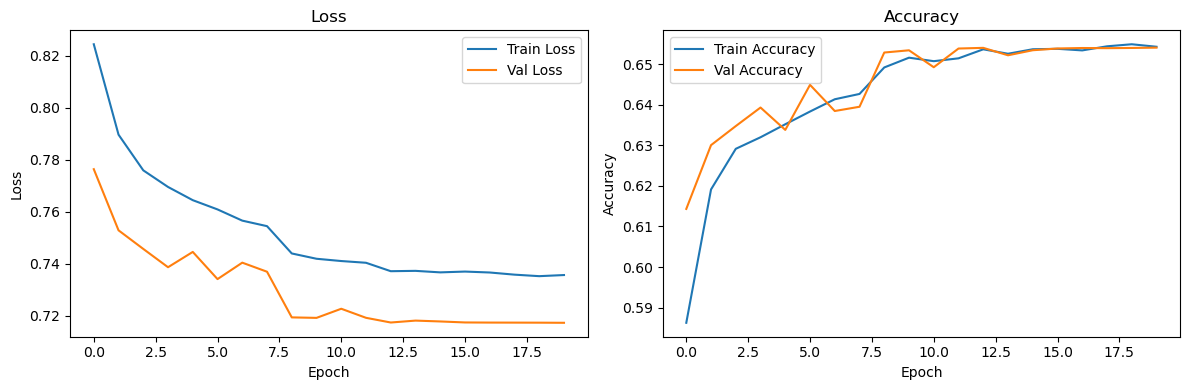

2444/2444 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

Validation set metrics (overall):
Accuracy: 0.6540
Micro-F1: 0.6540
Micro-Recall: 0.6540
Micro-Precision: 0.6540


In [9]:
# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(best_model.history_['loss'], label='Train Loss')
plt.plot(best_model.history_['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(best_model.history_['accuracy'], label='Train Accuracy')
plt.plot(best_model.history_['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate on validation set
val_preds = best_model.predict(X_val)
val_preds = val_preds + 1  # Convert back to 1, 2, 3
val_y = y_val  # Original labels (1, 2, 3)

# Compute overall metrics
print("\nValidation set metrics (overall):")
print(f"Accuracy: {accuracy_score(val_y, val_preds):.4f}")
print(f"Micro-F1: {f1_score(val_y, val_preds, average='micro'):.4f}")
print(f"Micro-Recall: {recall_score(val_y, val_preds, average='micro'):.4f}")
print(f"Micro-Precision: {precision_score(val_y, val_preds, average='micro'):.4f}")


Per-class metrics:
              precision    recall  f1-score   support

     Grade 1       0.70      0.20      0.31      7537
     Grade 2       0.63      0.95      0.76     44478
     Grade 3       0.81      0.29      0.42     26166

    accuracy                           0.65     78181
   macro avg       0.72      0.48      0.50     78181
weighted avg       0.70      0.65      0.60     78181

X_test columns: ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 

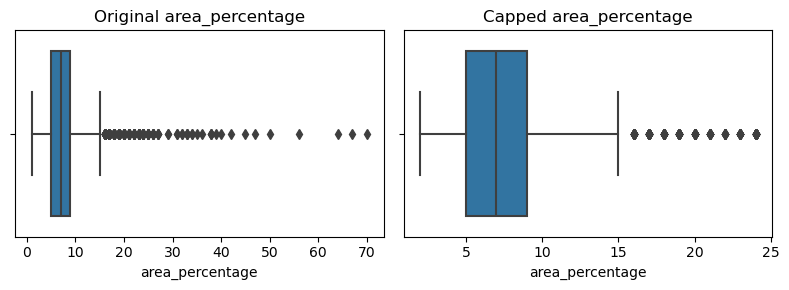

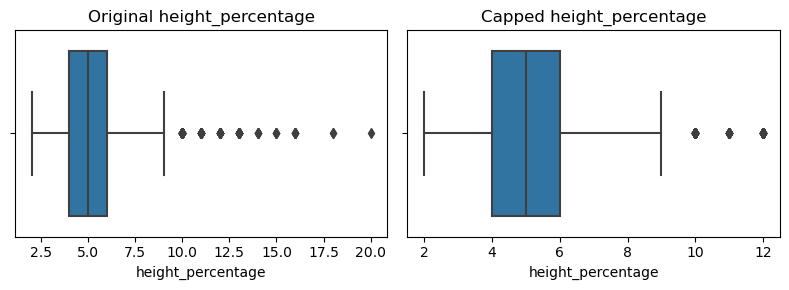

In [10]:
# Compute per-class metrics
print("\nPer-class metrics:")
print(classification_report(val_y, val_preds, target_names=['Grade 1', 'Grade 2', 'Grade 3']))

# Predict on test set
try:
    test_df = pd.read_csv('test_values.csv')
    ids = test_df['building_id']
    X_test = test_df[X_train.columns]
    print("X_test columns:", X_test.columns.tolist())
    test_preds = best_model.predict(X_test)
    test_preds = test_preds + 1

    pd.DataFrame({
        'building_id': ids,
        'damage_grade': test_preds
    }).to_csv('tuned_embedded_dnn_submission_balanced_augmented_enhanced.csv', index=False)
    print("Submission saved to 'tuned_embedded_dnn_submission_balanced_augmented_enhanced.csv'")
except FileNotFoundError:
    print("Error: 'test_values.csv' not found. Please ensure the file is in the working directory.")

# Visualize outlier capping
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    qs = X[['area_percentage', 'height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    for col in ['area_percentage', 'height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

sample = df[['area_percentage', 'height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)
for col in ['area_percentage', 'height_percentage']:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"Original {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"Capped {col}")
    plt.tight_layout()
    plt.show()